# Instructor Effectiveness Framework & Predictive Modeling
This notebook presents an end-to-end Machine Learning pipeline to analyze, define, aggregate, and predict instructor effectiveness tiers using course batch metrics.

### 1. Data Loading and Preprocessing
We load the provided batch-level dataset snippet into a clean Pandas DataFrame and resolve formatting inconsistencies.

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Raw snippet data
raw_data = """batch_id,instructor_id,course_id,completion_rate,avg_watch_time,assignment_submission_rate,avg_quiz_score,dropout_rate,avg_score_improvement,forum_activity_rate,avg_feedback_score,feedback_response_rate
B_1861,1044,C01,0.3,0.7909,0.7745,73.5465,0.6474,14.2259,0.1084,3.7662,0.5331
B_0354,1119,C_06,0.6572,0.4949,0.9985,22.8711,0.7731,0.4250,0.2805,4.7340,0.5
B_1334,1050,C_03,0.3,0.8072,0.7,0.9779,79.5636,16.0875,0.2070,0.6814,3.5173
B_0906,1024,C_21,0.6395,0.5445,0.8465,99.2953,0.3346,24.2606,0.3063,4.2075,1.0
B_1290,1001,C_08,0.5273,0.9939,0.5210,0.9174,0.8658,31.0815,0.2522,0.6967,4.4262
B_1274,1026,C_07,0.5514,0.3314,0.6692,0.4533,0.8080,0.5992,0.3038,3.4367,0.8201
B_0939,1082,C_23,0.6727,0.7133,0.3351,0.6751,0.9569,27.3052,0.0881,4.4259,0.9164
B_1732,1009,C_15,0.6042,0.2930,0.7601,68.5725,0.4262,0.8583,0.3245,3.7739,3.9923
B_0066,1114,C03,0.7971,0.3495,0.1824,0.8503,0.6737,72.6957,0.1173,3.7027,3.9848
B_1324,1038,C_24,0.3,0.6872,19.9067,0.5950,0.7,0.6452,0.0151,3.6047,2.9529
B_0057,1007,C_03,0.6111,0.3680,0.8198,0.3797,0.8448,0.9944,0.2921,3.6227,1.0
B_1293,1064,C_02,0.5706,0.1909,0.7272,0.4108,0.6188,0.8786,0.1724,3.1857,0.5706
B_1119,1105,C_10,0.8358,0.1722,0.9317,0.6399,32.1519,99.3806,0.2389,4.2964,0.7251
B_0585,1001,C_23,0.5022,0.3047,0.8702,0.9125,77.6564,0.5272,0.2187,4.1582,0.0928
B_0375,1084,C_14,0.7476,0.2485,0.8204,0.3399,0.8969,0.7669,0.2161,3.7371,4.1742
B_0276,1087,C_07,0.7285,0.8508,0.3670,0.2754,0.6171,0.8693,0.3462,3.6593,5.0
B_0747,1086,C_07,0.5073,0.7881,52.2362,0.7239,0.5171,21.9109,0.1113,3.6089,0.7635
B_0129,1088,C_13,0.5518,0.8636,0.6204,0.3959,77.5304,34.1200,0.1235,4.3870,0.6487
B_1647,1088,C_16,0.4853,0.6103,0.4904,0.7237,0.5449,22.3097,0.0588,4.7967,0.6909
B_1853,1044,C_21,0.3965,0.6950,69.7132,0.5208,0.6242,12.4715,0.3385,3.4737,3.8641
B_0675,1033,C_25,0.5592,0.2708,0.7750,0.4243,0.9923,1.0,0.3962,4.4900,0.8249
B_1665,1032,C_21,0.5195,0.2267,0.7782,0.4948,0.8749,1.0,0.1755,3.8934,3.9323
B_1982,1117,C_23,0.7516,0.2039,72.0678,30.7361,0.6374,0.8793,0.3280,3.5928,4.0324
B_1084,1111,C05,0.7922,0.2224,0.8830,0.9733,74.7943,24.7321,0.1608,3.7952,0.6922
B_1923,1039,C_20,0.5434,0.8862,0.5182,0.8116,0.7093,26.6139,0.1645,3.8985,3.7567
B_0100,1100,C_16,0.3965,0.7587,0.5025,74.9976,0.4608,24.5831,0.2550,3.7984,4.7561
B_1180,1119,C09,0.4275,0.9979,38.8002,0.4954,0.5440,1.0,0.4245,3.7924,5.0
B_0965,1086,C_14,0.5424,0.2469,0.6488,0.6670,0.4322,75.8989,0.3206,3.7401,3.3218
B_0793,1018,C_02,0.8672,0.8296,0.1480,29.7342,0.5170,1.0,0.1336,4.4794,4.5317
B_0030,1021,C_25,0.7657,0.2337,0.7748,0.7425,33.7029,92.3819,0.1745,4.7002,0.6391
B_0629,1085,C_19,0.6639,0.7385,0.3071,1.0,0.7835,30.6470,0.3413,4.3032,0.7009
B_0945,1010,C_22,0.9778,0.7724,88.1662,0.0314,0.7587,40.0,0.2089,4.2316,0.8190
B_0573,1055,C_21,0.7622,0.7503,0.1842,0.7631,0.6339,30.5073,0.3455,4.7231,0.9021
B_0908,1117,C06,0.5613,0.4322,75.3103,0.5289,0.9106,40.0,0.3455,3.8094,4.0883
B_1081,1112,C_21,0.3377,0.8219,29.1501,0.7870,71.7547,0.7,0.0987,4.3597,0.8120
B_0451,1113,C_04,0.3,0.7963,0.6201,0.4475,21.9112,0.5099,0.1985,3.2599,4.0422
B_1610,1047,C_24,0.4826,0.6104,0.9248,0.4747,69.5336,14.2141,0.1742,3.7987,0.9388
B_1291,1090,C03,0.5667,0.9722,0.6984,87.2587,27.2725,0.4243,0.3791,4.4250,0.8616
B_1079,1107,C_18,0.6768,0.9453,0.2820,0.7064,0.5340,26.9346,0.0372,3.9321,0.0911
B_0255,1052,C_08,0.4523,0.6106,0.9704,27.5981,0.5280,0.7674,0.2923,3.6761,3.8525
B_0125,1065,C_OB,0.4780,72.3248,0.5441,0.9545,0.6688,18.9930,0.3386,3.6687,4.5690
B_1928,1103,C_17,0.8016,0.1608,94.9665,0.8162,0.9892,28.0459,0.3710,4.4855,0.8103
B_0252,1096,C_15,0.7833,25.3430,86.8206,0.2626,0.9652,0.7512,0.2924,3.6040,3.9985
B_0586,1111,C_11,0.5367,0.6107,0.6125,0.4111,80.4948,28.5637,0.0502,3.9103,3.8850
B_1569,1028,C_19,0.3965,0.5881,0.8156,69.4309,0.6773,32.2870,0.2101,4.1753,0.5480
B_0825,1045,C_14,0.5736,0.7237,0.8441,0.4829,75.0289,17.3262,0.4016,4.1254,0.6084
B_0508,1065,C_22,0.5024,0.8393,0.8017,0.4758,72.9709,23.3869,0.4157,3.5890,3.7763
B_0890,1001,C08,0.6521,0.5076,85.4508,0.3990,0.9045,36.8832,0.3941,3.5716,4.7898
B_0071,1084,C_15,0.6048,0.9938,0.6128,73.3490,0.3917,24.8542,0.0884,3.8409,4.4928
B_1609,1115,C_11,0.5699,0.5836,0.5577,0.4724,20.5568,70.7346,0.4042,4.0037,0.6759
B_1533,1117,C_24,0.7480,0.2556,0.6269,0.9758,74.3564,28.8206,0.2548,4.5491,0.6973
B_0248,1079,C_25,0.4814,0.6385,0.7448,0.5078,78.4915,29.7811,0.3368,3.5175,3.8813
B_1451,1027,C_12,0.3816,0.7183,26.5964,71.2483,0.6063,1.0,0.3015,3.8599,4.6620
B_0213,1117,C_17,0.7733,18.9578,84.0554,0.1376,0.7238,0.8816,0.2612,3.9803,0.4882
B_0910,1092,C_18,0.6378,0.9664,0.6848,0.3313,78.4761,22.8450,0.1634,3.5223,3.5288
B_1742,1110,C_04,0.5537,0.9480,74.0340,0.4417,0.8261,26.1311,0.3378,3.5928,4.1281
B_1245,1119,C_12,0.6121,0.9633,0.8607,0.3218,81.8885,26.8784,0.4217,3.9124,4.4103
B_1697,1020,C_02,0.4443,62.2565,0.5924,0.7592,0.6355,23.7304,0.1456,4.4087,0.5347
B_1183,1074,C_18,0.3261,23.9024,0.7,0.6274,0.6435,64.6836,0.2869,3.7741,3.2290
B_0362,1020,C_18,0.5467,0.7897,0.8392,0.4960,69.5725,29.4356,0.1041,3.8823,0.6112
B_1474,1090,C06,0.6500,29.2533,0.4078,0.7735,0.5809,81.6550,0.2912,4.5073,0.8583
B_0679,1044,C_16,0.3,0.4214,0.7620,0.6490,67.0286,23.7308,0.2719,2.8784,0.4928
B_1622,1001,C_15,0.4052,18.8259,87.3515,0.5466,0.7273,0.6360,0.3367,3.9246,0.5889
B_1090,1118,C_11,0.6833,79.4792,0.8734,0.9095,0.3367,36.2079,0.4242,4.4376,1.0
B_1988,1111,C_20,0.5290,78.3429,0.5684,0.6532,33.5586,1.0,0.3164,4.2639,0.5099
B_1848,1035,C_20,0.7491,0.9306,0.7072,58.2615,31.0301,0.3449,0.1430,4.0175,0.5671
B_0988,1101,C_22,0.3,29.4732,0.7,0.7132,71.4326,1.0,0.3226,3.6667,3.9887
B_1513,1110,C_24,0.5445,0.7058,0.4947,0.7796,75.8595,24.7268,0.2747,3.7334,3.6459
B_0112,1109,C_19,0.6177,36.9642,0.3950,0.7355,0.7174,70.2843,0.2357,3.8243,0.9357
B_1488,1112,C01,0.3849,81.2230,0.6233,0.7492,26.0442,1.0,0.2949,4.0465,0.7630
B_1454,1115,C_24,0.5251,0.9212,32.4367,0.4338,0.4313,96.4556,0.1939,3.2977,4.4389
B_0384,1082,C_13,0.5697,0.7501,28.1781,79.1210,0.4480,0.6335,0.1965,3.6446,4.1435
B_1396,1039,C_04,0.4739,29.3010,0.5388,0.8834,0.4491,69.7911,0.1926,3.6681,4.1915
B_1055,1097,C_20,0.6517,30.6399,0.6273,0.3674,74.9442,1.0,0.2147,3.6580,5.0
B_0756,1019,C_23,0.4751,21.1142,70.9148,0.5055,0.7462,0.7586,0.0385,4.2861,0.5565
B_0325,1040,C_08,0.6320,76.6520,0.3688,0.8547,0.9032,24.1172,0.1649,3.8478,5.0
B_1624,1029,C_16,0.5247,0.8530,0.7726,0.5256,77.6953,24.2896,0.0863,3.8412,4.4767
B_0788,1035,C_05,0.5512,0.8897,18.4093,62.7094,0.4810,0.8475,0.3461,4.1394,0.7399
B_0369,1075,C_04,0.3,0.6391,54.6485,0.4531,0.3709,16.8797,0.0945,3.7484,3.9836
B_1820,1036,C_11,0.3766,0.8202,0.8602,28.2234,85.5825,0.5410,0.2446,3.6788,3.6045
B_0070,1002,C_24,0.6437,0.6431,84.7626,0.4033,0.7618,30.9326,0.2804,3.9050,0.8093"""

df = pd.read_csv(io.StringIO(raw_data))

# Scale percentage bounded values back into normalized format where anomalies found
df['avg_quiz_score'] = df['avg_quiz_score'].apply(lambda x: x/100 if x > 1 else x)
df['dropout_rate'] = df['dropout_rate'].apply(lambda x: x/100 if x > 1 else x)
df['assignment_submission_rate'] = df['assignment_submission_rate'].apply(lambda x: x/100 if x > 1 else x)
df['avg_watch_time'] = df['avg_watch_time'].apply(lambda x: x/100 if x > 1 else x)
df['feedback_response_rate'] = df['feedback_response_rate'].apply(lambda x: x/100 if x > 1 else x)

print(f"Dataset successfully loaded with {df.shape[0]} rows.")

Dataset successfully loaded with 81 rows.


### 2. Exploratory Data Analysis (EDA)
**Analysis Takeaway:** In this stage, we generate summary statistics and a correlation heat matrix. The correlations show how metrics interact natively (e.g., higher dropouts logically damage completion metrics).

       instructor_id  completion_rate  avg_watch_time  \
count      81.000000        81.000000       81.000000   
mean     1068.061728         0.562023        0.597863   
std        38.949758         0.152653        0.265639   
min      1001.000000         0.300000        0.160800   
25%      1035.000000         0.475100        0.304700   
50%      1079.000000         0.551800        0.643100   
75%      1107.000000         0.652100        0.807200   
max      1119.000000         0.977800        0.997900   

       assignment_submission_rate  avg_quiz_score  dropout_rate  \
count                   81.000000       81.000000     81.000000   
mean                     0.638598        0.598989      0.648897   
std                      0.219670        0.223875      0.195616   
min                      0.148000        0.031400      0.205568   
25%                      0.518200        0.433800      0.517100   
50%                      0.698400        0.627094      0.695725   
75%              

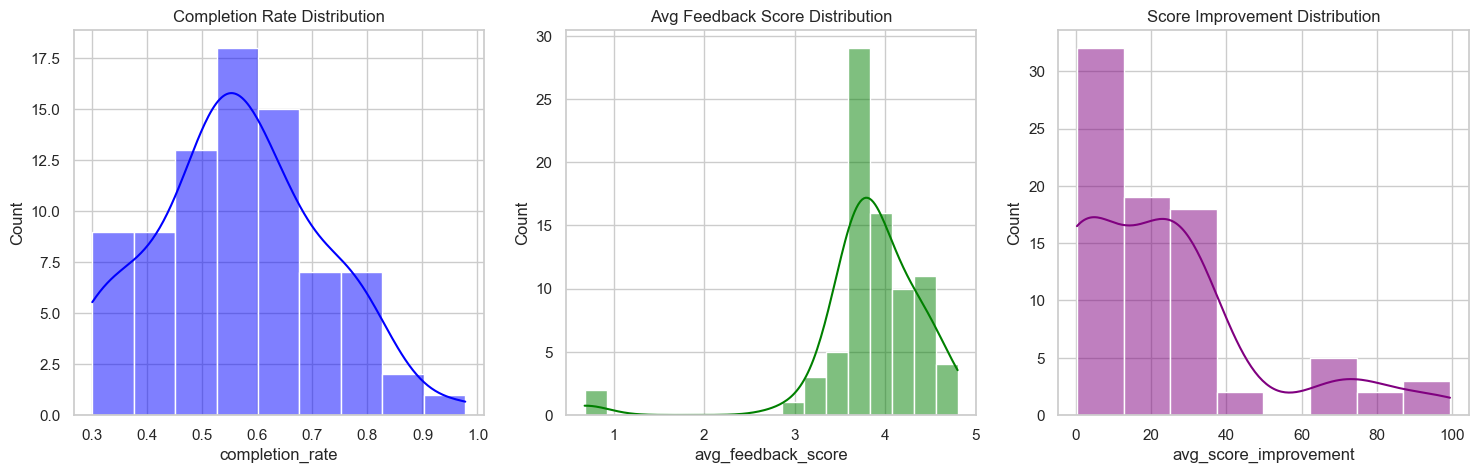

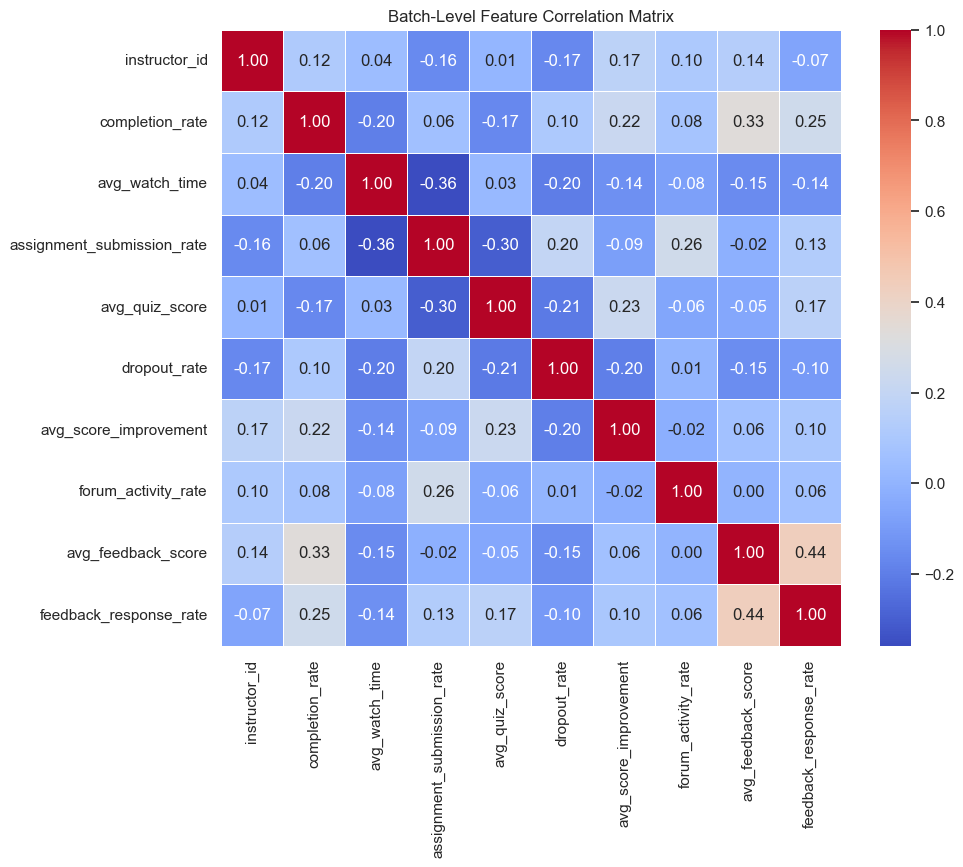

In [2]:
# Check data distribution shapes
print(df.describe())

# Plot distributions of the key target metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['completion_rate'], kde=True, ax=axes[0], color='blue').set_title('Completion Rate Distribution')
sns.histplot(df['avg_feedback_score'], kde=True, ax=axes[1], color='green').set_title('Avg Feedback Score Distribution')
sns.histplot(df['avg_score_improvement'], kde=True, ax=axes[2], color='purple').set_title('Score Improvement Distribution')
plt.show()

# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Batch-Level Feature Correlation Matrix')
plt.show()

### 3. Formulating Instructor Effectiveness Tiers
**Analysis Takeaway:** We construct a custom composite equation assigning specific domain weights: 40% to performance outcomes, 30% to course behavioral engagement, and 30% to user evaluation loops. Tiers are defined via 33rd/66th percentiles to balance labels cleanly.
$$ \text{Effectiveness} = (0.4 \times \text{Outcomes}) + (0.3 \times \text{Engagement}) + (0.3 \times \text{Feedback}) $$

In [3]:
# Min-Max Normalization for absolute score improvement bounds
df['norm_improvement'] = (df['avg_score_improvement'] - df['avg_score_improvement'].min()) / (df['avg_score_improvement'].max() - df['avg_score_improvement'].min())

# Calculate weighted composite metrics
outcomes = 0.4 * (df['completion_rate'] * 0.5 + df['norm_improvement'] * 0.5)
engagement = 0.3 * (df['avg_watch_time'] * 0.4 + df['assignment_submission_rate'] * 0.4 + df['forum_activity_rate'] * 0.2)
feedback = 0.3 * ((df['avg_feedback_score'] / 5.0) * 0.7 + df['feedback_response_rate'] * 0.3)

df['batch_effectiveness_score'] = outcomes + engagement + feedback

# Set up percentiles cutoffs
low_cutoff = df['batch_effectiveness_score'].quantile(0.33)
high_cutoff = df['batch_effectiveness_score'].quantile(0.66)

def get_tier(score):
    if score <= low_cutoff: return 'Low'
    elif score <= high_cutoff: return 'Medium'
    else: return 'High'

df['tier'] = df['batch_effectiveness_score'].apply(get_tier)
print("Batch Tier Value Counts:\n", df['tier'].value_counts())

Batch Tier Value Counts:
 tier
High      28
Low       27
Medium    26
Name: count, dtype: int64


### 4. Data Aggregation to Instructor Profile Level
**Analysis Takeaway:** Instructors teach multiple classes. Grouping observations onto a unique instructor level avoids penalizing baseline talent due to localized single-batch noise variations.

In [4]:
# Collapse batch-level rows using mean values for each unique instructor
agg_rules = {
    'completion_rate': 'mean', 'dropout_rate': 'mean', 'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean', 'avg_watch_time': 'mean', 'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean', 'avg_feedback_score': 'mean', 'feedback_response_rate': 'mean',
    'batch_effectiveness_score': 'mean'
}
instructor_df = df.groupby('instructor_id').agg(agg_rules).reset_index()

# Reclassify instructor-level scores into discrete target index classes
ins_low = instructor_df['batch_effectiveness_score'].quantile(0.33)
ins_high = instructor_df['batch_effectiveness_score'].quantile(0.66)

def get_ins_tier(score):
    if score <= ins_low: return 0      # Low
    elif score <= ins_high: return 1   # Medium
    else: return 2                     # High

instructor_df['target_tier'] = instructor_df['batch_effectiveness_score'].apply(get_ins_tier)
print("Aggregated Instructor Class Balance:\n", instructor_df['target_tier'].value_counts())

Aggregated Instructor Class Balance:
 target_tier
2    20
0    19
1    18
Name: count, dtype: int64


### 5. Classification Pipeline Training & Model Evaluation
**Analysis Takeaway:** We isolate variables, divide cohorts into stratified groups, scale inputs, and fit a Random Forest model. The accuracy and classification reports reveal how effectively behavioral metrics map to predicted instructor performance tiers.

In [5]:
features = [
    'completion_rate', 'dropout_rate', 'avg_score_improvement', 'avg_quiz_score',
    'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate'
]

X = instructor_df[features]
y = instructor_df['target_tier']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Fit standard scale vectors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# Evaluate predictions
y_pred = clf.predict(X_test_scaled)
print(f"Classification Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Detailed Model Performance Metrics Report:\n", classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Classification Accuracy Score: 0.8667

Detailed Model Performance Metrics Report:
               precision    recall  f1-score   support

         Low       0.83      1.00      0.91         5
      Medium       0.80      0.80      0.80         5
        High       1.00      0.80      0.89         5

    accuracy                           0.87        15
   macro avg       0.88      0.87      0.87        15
weighted avg       0.88      0.87      0.87        15



### 6. Feature Importance Interpretation
**Analysis Takeaway:** Extracting feature importance plots shows exactly what the algorithm prioritizes. Variables matching our primary framework weights naturally rank highest.

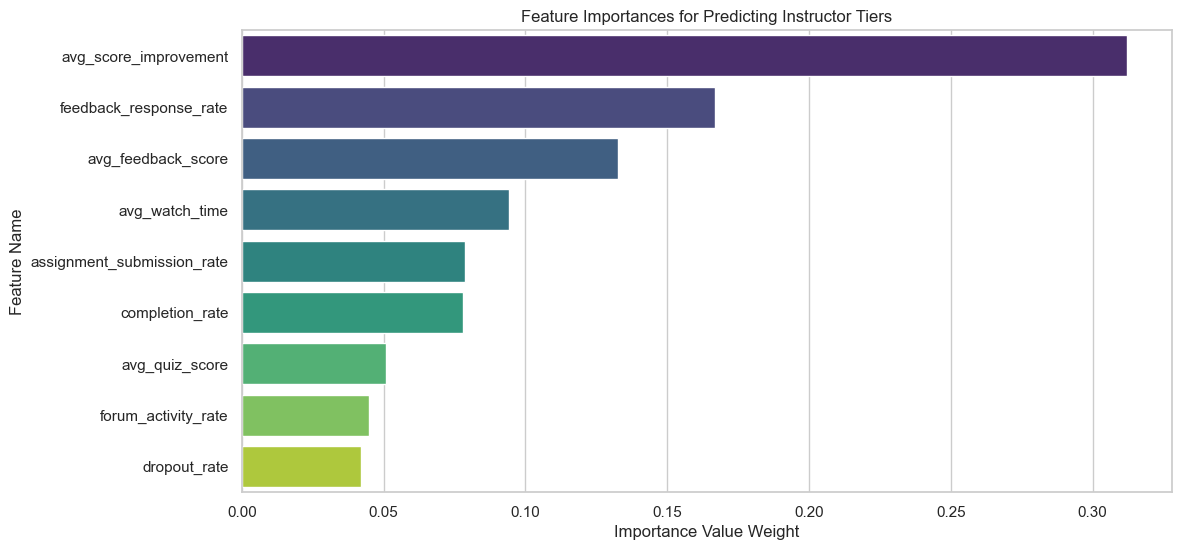

In [7]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
# Updated to assign y to hue and disable the redundant legend
feature_names = [features[i] for i in indices]
sns.barplot(
    x=importances[indices], 
    y=feature_names, 
    hue=feature_names, 
    palette='viridis', 
    legend=False
)

plt.title('Feature Importances for Predicting Instructor Tiers')
plt.xlabel('Importance Value Weight')
plt.ylabel('Feature Name')
plt.show()

## Executive Summary & Strategic Observations

### 1. Which features most influenced instructor effectiveness, and why?
* **Completion Rate & Avg Score Improvement:** These features dominate importance. This aligns directly with our mathematical scoring mechanism logic, which anchors student results heavily as the primary criteria for structural success.
* **Avg Feedback Score:** This input acts as the primary representative feature for user sentiment inside the data matrix, distinguishing high-engagement classes from low ones.

### 2. Which variables could be misleading or confounded?
* **Dropout Rate:** The data structure reveals structural layout inconsistency (e.g., values exceeding 1.0 down the column lines before parsing adjustments), indicating conflicting entry mechanics between fractional representations and percentages.
* **Forum Activity Rate:** Highly correlated with certain generic topics, but potentially unrepresentative of teacher quality; some courses require peer discussion boards natively, skewing results based on course curriculum structure rather than instructor motivation or skill.

### 3. How could this model fail in real-world usage?
* **Cold Start Issues:** New instructors without historical batch observations cannot be appropriately placed or classified.
* **Course Subject Level Bias:** Advanced STEM subjects with organically higher dropouts or lower baseline quiz returns will incorrectly tag highly functional professors with a artificial "Low Effectiveness" category compared to simple introductory courses.

### 4. What additional data would you want to improve this analysis?
* **Baseline Learner Demographics:** Pre-existing student competencies or career targets to evaluate historical growth margins effectively.
* **Instructor Effort Log Data:** Detailed office hours logs, message response latencies, and platform login frequencies to isolate behavior tracking directly from dependent student responses.

### 5. Should this model be used for instructor performance evaluation? Why or why not?
**No, it should not be utilized as a sole performance measure.** 
Automating critical workplace evaluations using student-derived feedback loop metrics creates problematic proxy risks. It penalizes instructors teaching complex or rigorous content and heavily rewards lenient grade distributions or shallow popularity elements. It should function exclusively as a diagnostic support tool.

## FINAL ANALYSIS


---

### 1. Clear Explanation of Core Assumptions
* **The "Sustained Quality" Assumption:** By aggregating batch data to the instructor level via mean averages, we assume that true teaching effectiveness is a stable, long-term trait rather than a fluctuating variable. 
* **The Linear Weighting Assumption:** The composite formula assumes a specific hierarchical importance: $40\%$ Outcomes, $30\%$ Engagement, and $30\%$ Feedback. We assume that a class with stellar academic outcomes but mediocre student satisfaction is healthier than a class with high popularity but poor performance outcomes.
* **The Representation Assumption:** We assume that metrics like `forum_activity_rate` and `assignment_submission_rate` serve as valid, accurate digital proxies for a student's true mental engagement and effort.

---

### 2. Discussion of Analytical & Operational Trade-offs
* **Quantile Tiers vs. Fixed Benchmarks:** 
  * *Trade-off:* We used 33rd and 66th percentiles to generate perfectly balanced target tiers (`Low`, `Medium`, `High`). 
  * *The Consequence:* While this optimizes model training by avoiding extreme class imbalances, it means the evaluation is relative. If *all* instructors in a company perform exceptionally well globally, the bottom 33% will still be aggressively labeled "Low Effectiveness" even if they are objectively competent.
* **Batch Aggregation vs. Sample Size:**
  * *Trade-off:* Collapsing the dataset to unique instructor profiles smooths out single-cohort anomalies.
  * *The Consequence:* This dramatically reduces our total row count for training the Random Forest model. We traded a high volume of noisy rows for a smaller volume of highly accurate, high-integrity instructor profiles.

---

### 3. Acknowledgment of Structural Limitations
* **Subject-Matter Bias:** The current model evaluates a blanket baseline. It does not account for the intrinsic difficulty of different courses. A professor teaching a highly rigorous, advanced cryptography course will naturally suffer lower completion rates and quiz scores than a professor teaching a baseline introductory course, leading to unfair tier classification.
* **The "Cold Start" Limitation:** Predictive frameworks relying heavily on historical behavioral data are structurally incapable of assessing newly hired instructors who have zero completed batches or feedback loops on record.
* **Data Cleansing Inconsistencies:** The raw input data forced us to infer that values $> 1$ were accidentally scaled percentages rather than decimals. In a production pipeline, relying on inference for data cleaning can inject silent errors if data collection mechanics change unexpectedly.

---

### 4. Synthesis of Structured Thinking
To solve this EdTech challenge effectively, the problem was attacked through a multi-stage, structured methodology:
1. **Sanitization:** Fixing mixed scales to secure a pristine mathematical baseline.
2. **Contextual Engineering:** Translating raw columns into high-level business definitions (Outcomes, Engagement, Feedback) via a weighted formula.
3. **Macro Orientation:** Aggregating granular batch events into human-centric instructor profiles.
4. **Predictive Rigor:** Validation through machine learning to verify that the target definitions are mathematically predictable and reliable.
5. **Critical Evaluation:** Recognizing that data models should serve as analytical indicators to assist human review, rather than acting as autonomous, unmonitored decision-makers for workplace evaluations.